<a href="https://colab.research.google.com/github/oooinr4018-web/-1/blob/main/ESAA_0619_%EA%B3%BC%EC%A0%9C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from mpl_toolkits.mplot3d import Axes3D

In [5]:
data=pd.read_csv('Mall_Customers.csv')
data.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [6]:
data.shape

(200, 5)

In [7]:
data.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


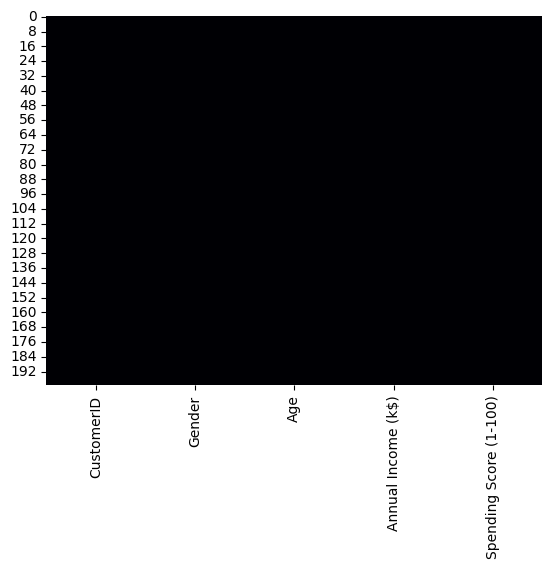

In [10]:
sns.heatmap(data.isnull(), cmap='magma', cbar=False);

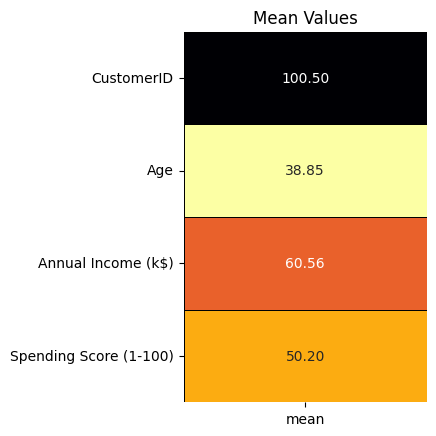

In [14]:
fig,ax=plt.subplots(nrows=1, ncols=1, figsize=(5,5))

plt.subplot(1,1,1)
sns.heatmap(data.describe().T[['mean']], cmap='inferno_r', annot=True, fmt='.2f', linecolor='black', linewidths=0.4, cbar=False);
plt.title('Mean Values');

fig.tight_layout(pad=3)

In [17]:
col=list(data.columns)
categorical_features=[]
numerical_features=[]
for i in col:
  if len(data[i].unique())>6:
    numerical_features.append(i)
  else:
    categorical_features.append(i)

print('Categorical Features :', categorical_features)
print('Numerical Features :', numerical_features)

Categorical Features : ['Gender']
Numerical Features : ['CustomerID', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']


In [19]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df1=data.copy(deep=True)

df1['Gender']=le.fit_transform(df1['Gender'])

print('Label Encoder Transformation')
print(df1['Gender'].unique(), '=', le.inverse_transform(df1['Gender'].unique()))

Label Encoder Transformation
[1 0] = ['Male' 'Female']


/tmp/ipykernel_2130/3834506392.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df1[categorical_features[i]], kde_kws={'bw'
/usr/local/lib/python3.12/dist-packages/seaborn/distributions.py:2496: UserWarning: 

The `bw` parameter is deprecated in favor of `bw_method` and `bw_adjust`.
Setting `bw_method=1`, but please see the docs for the new parameters
and update your code. This will become an error in seaborn v0.14.0.

  kdeplot(**{axis: a}, ax=ax, color=kde_color, **kde_kws)
/tmp/ipykernel_2130/3834506392.py:12: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use eith

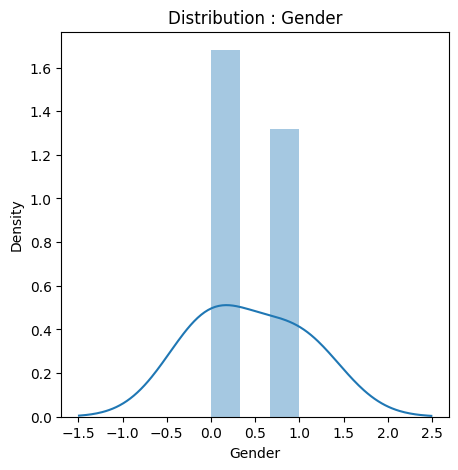

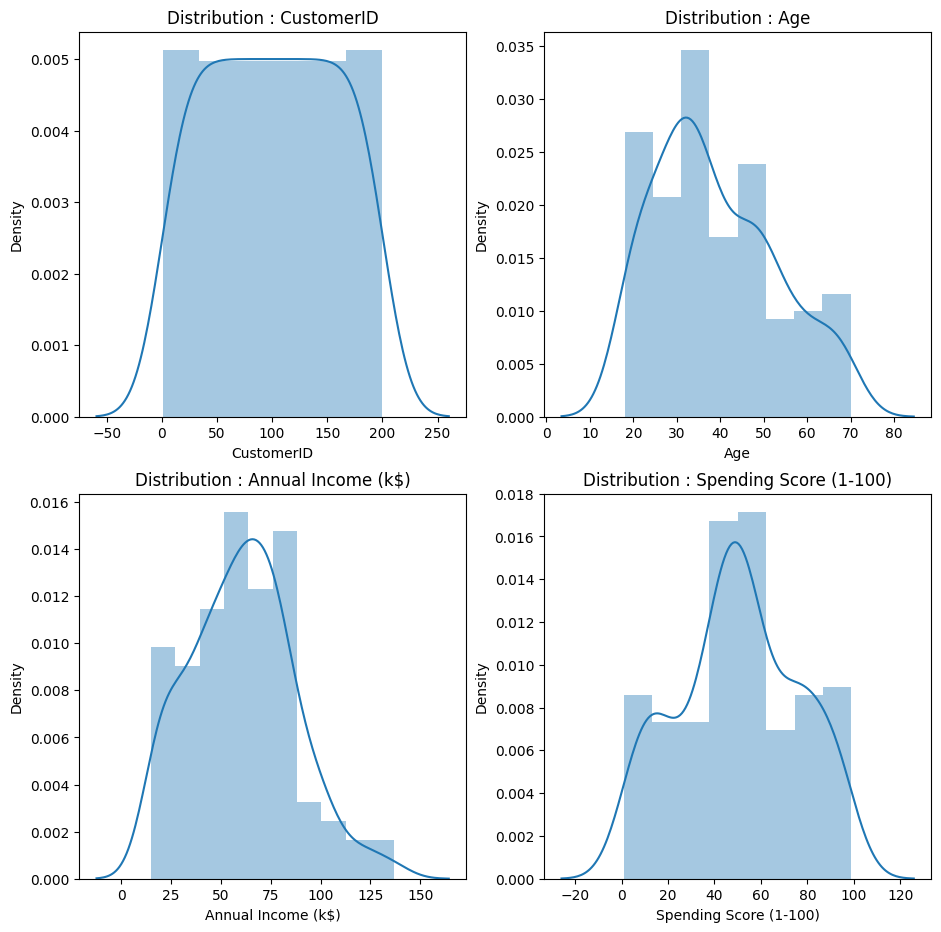

In [24]:
fig, ax=plt.subplots(nrows=1, ncols=1, figsize=(5,5))
for i in range(len(categorical_features)):
  plt.subplot(1,1,i+1)
  sns.distplot(df1[categorical_features[i]], kde_kws={'bw'
  :1});
  title='Distribution : ' + categorical_features[i]
  plt.title(title)

  fig, ax=plt.subplots(nrows=2, ncols=2, figsize=(11,11))
  for i in range(len(numerical_features)):
    plt.subplot(2,2,i+1)
    sns.distplot(data[numerical_features[i]],)
    title='Distribution : ' + numerical_features[i]
    plt.title(title)
  plt.show()

In [25]:
numerical_features.remove('CustomerID')

/tmp/ipykernel_2130/3803020101.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax=sns.countplot(x='Gender', data=df1, palette=colors, edgecolor='black');
/tmp/ipykernel_2130/3803020101.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Female', 'Male'])


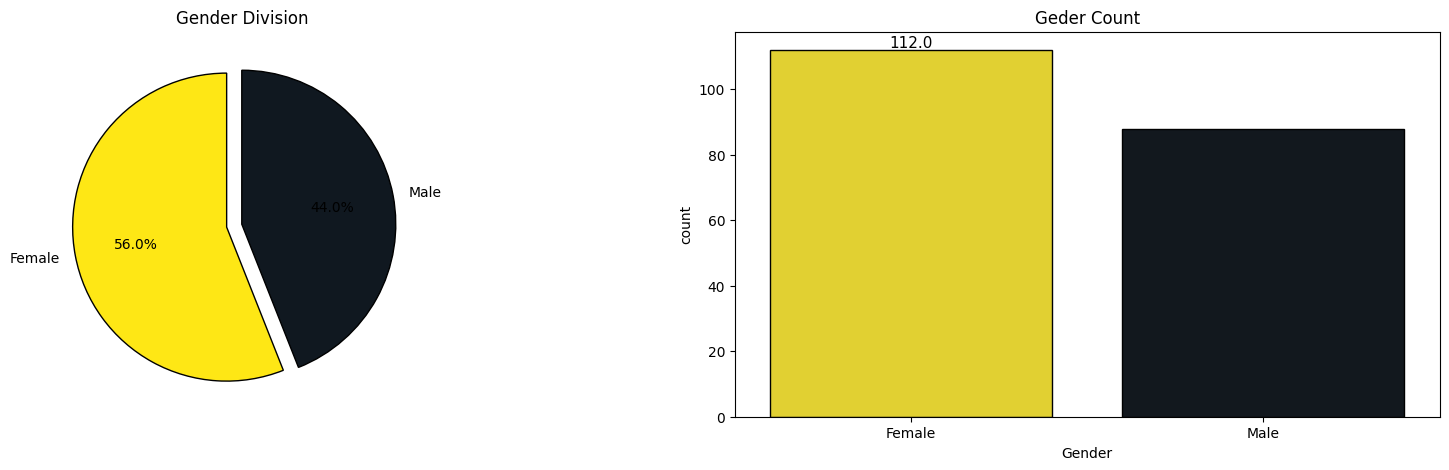

/tmp/ipykernel_2130/3803020101.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Female', 'Male'])


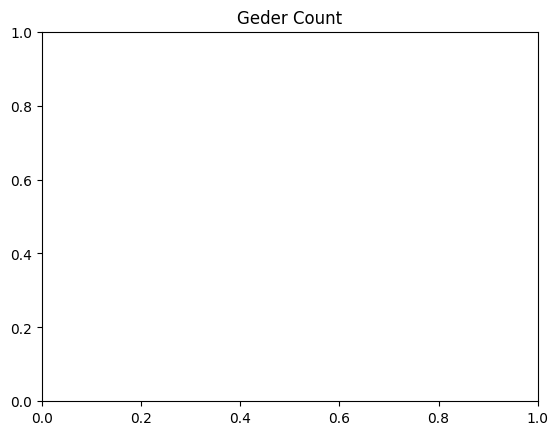

In [38]:
l=list(data['Gender'].value_counts())
circle=[l[0]/sum(l)*100, l[1]/sum(l)*100]
colors=['#FEE715', '#101820']

fig, ax=plt.subplots(nrows=1, ncols=2, figsize=(20,5))

plt.subplot(1,2,1)
plt.pie(circle, labels=['Female', 'Male'],autopct='%1.1f%%', startangle=90, explode=(0.1,0),colors=colors,
        wedgeprops={'edgecolor':'black','linewidth': 1, 'antialiased':True})
plt.title('Gender Division');

plt.subplot(1,2,2)
ax=sns.countplot(x='Gender', data=df1, palette=colors, edgecolor='black');
for rect in ax.patches:
  ax.text(rect.get_x()+rect.get_width()/2, rect.get_height()+0.75, rect.get_height(), horizontalalignment='center', fontsize=11)
  plt.title('Geder Count')
  ax.set_xticklabels(['Female', 'Male'])

  plt.show()

/tmp/ipykernel_2130/2312265405.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax=sns.barplot(x='Gender', y=numerical_features[i], palette=colors, data=df1)
/tmp/ipykernel_2130/2312265405.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Female','Male'])
/tmp/ipykernel_2130/2312265405.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax=sns.violinplot(x='Gender', y=numerical_features[i], palette=colors,data=df1)
/tmp/ipykernel_2130/2312265405.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Fem

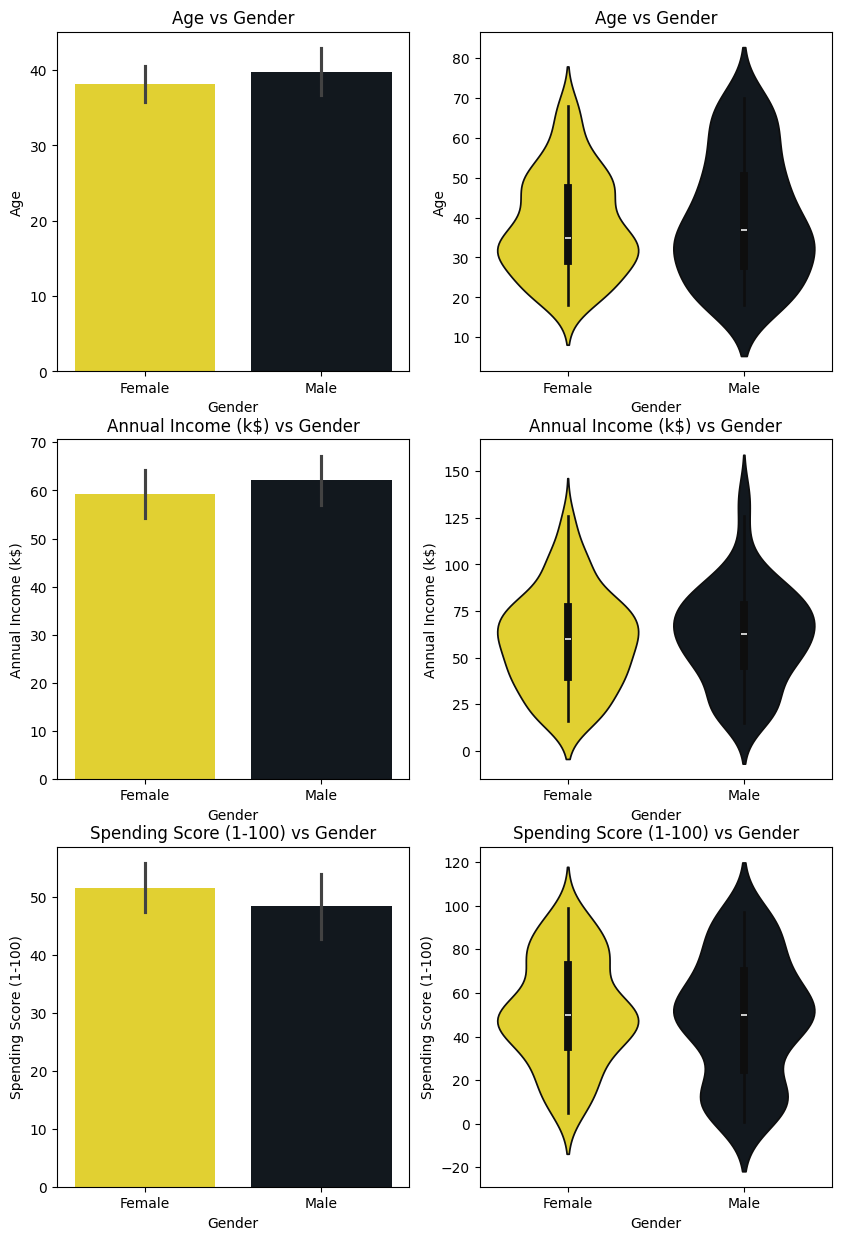

In [40]:
fig=plt.subplots(nrows=3, ncols=2, figsize=(10,15))
for i in range(len(numerical_features)):
  plt.subplot(3,2,(i*2)+1)
  ax=sns.barplot(x='Gender', y=numerical_features[i], palette=colors, data=df1)
  ax.set_xticklabels(['Female','Male'])
  title=numerical_features[i]+' vs Gender'
  plt.title(title)

  plt.subplot(3,2,(i*2)+2)
  ax=sns.violinplot(x='Gender', y=numerical_features[i], palette=colors,data=df1)
  ax.set_xticklabels(['Female','Male'])
  title=numerical_features[i]+' vs Gender'
  plt.title(title)

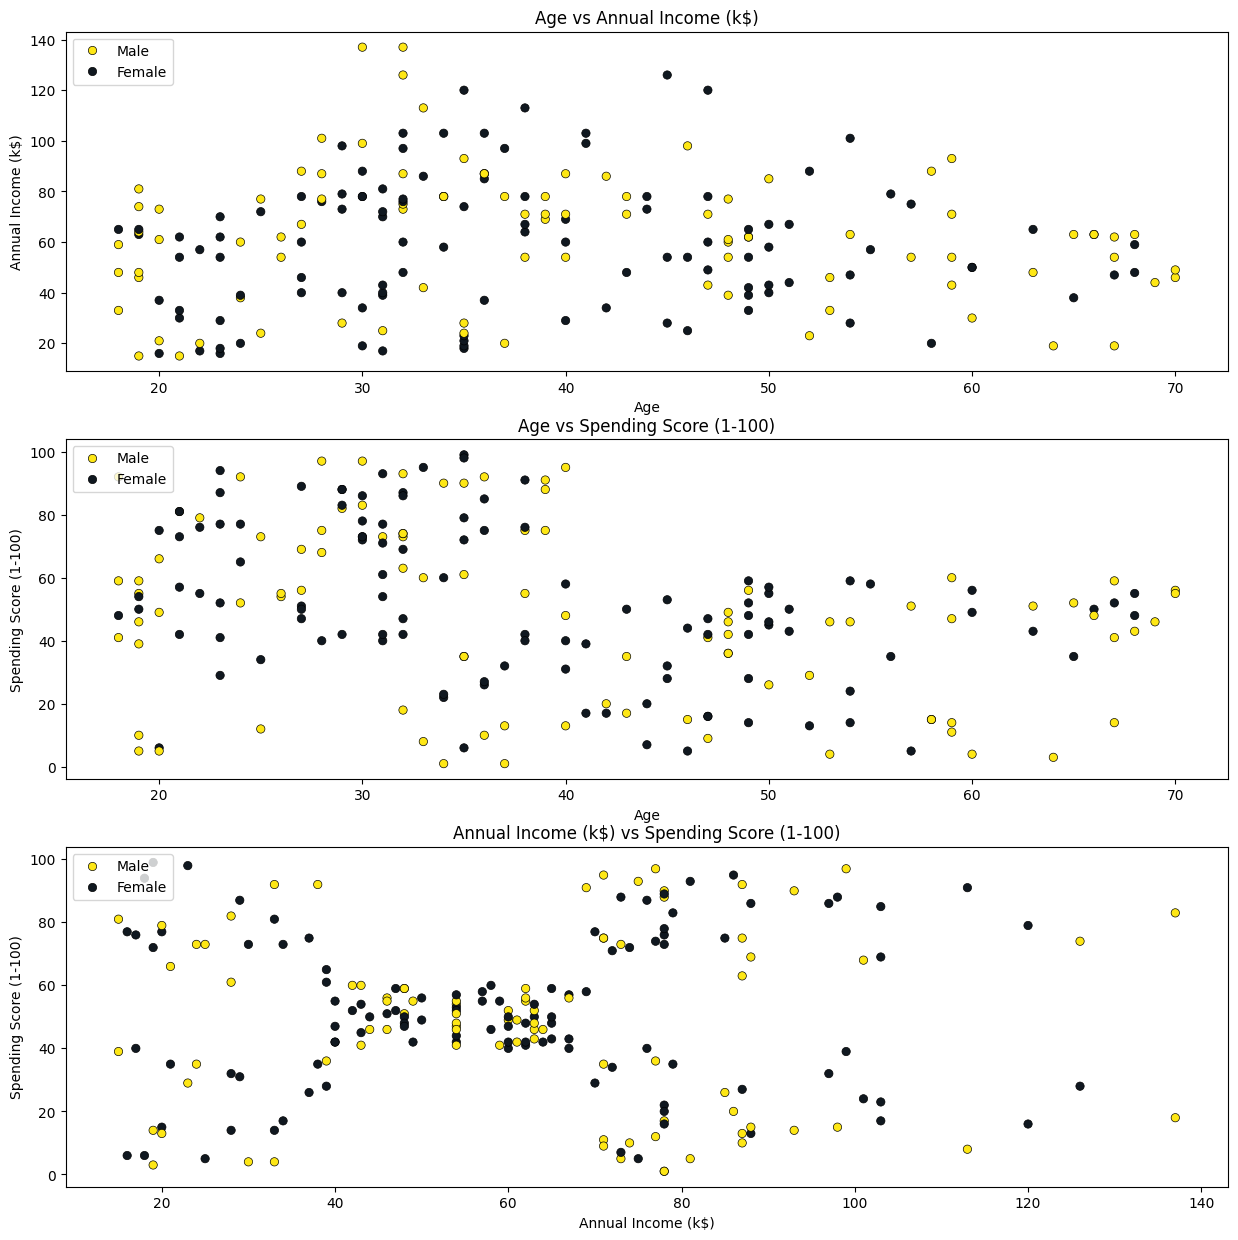

In [47]:
a=0
fig,ax=plt.subplots(nrows=3, ncols=1, figsize=(15,15))
for i in range(len(numerical_features)-1):
  for j in range(len(numerical_features)):
    if i!=j and j>i:
      a += 1
      plt.subplot(3,1,a)
      sns.scatterplot(x=numerical_features[i], y=numerical_features[j], data=data,
                      hue='Gender', palette=colors, edgecolor='black');

      plt.legend(loc='upper left',)
      title=numerical_features[i]+' vs ' + numerical_features[j]
      plt.title(title)

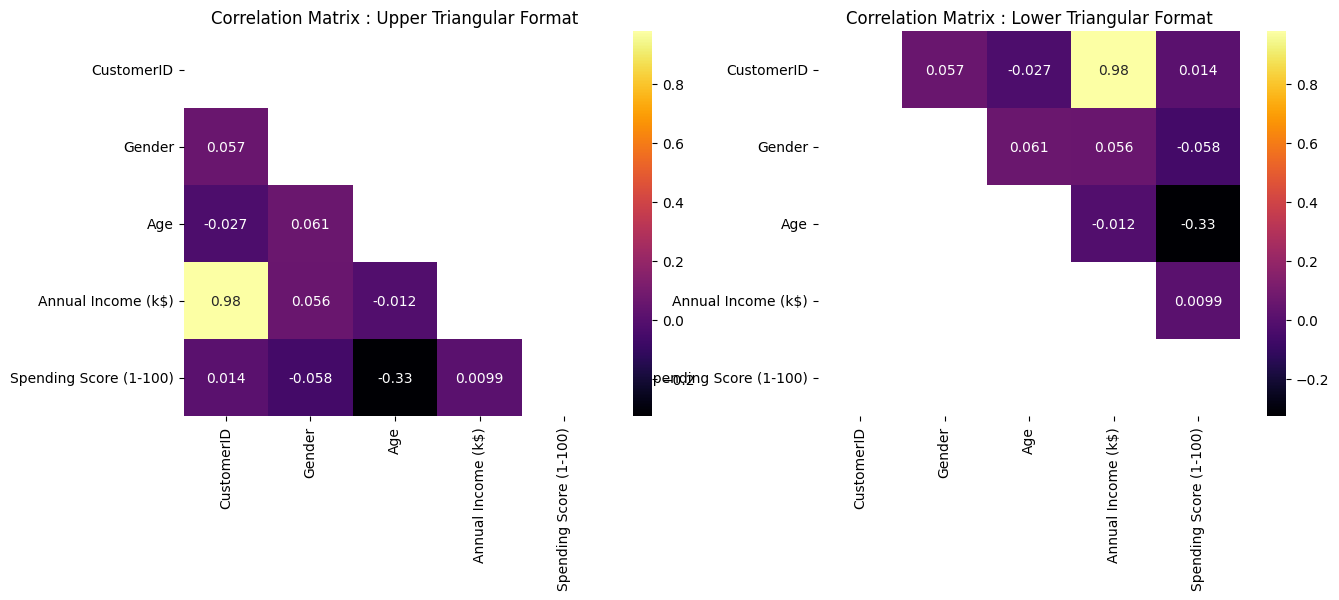

In [57]:
corr = df1.corr(numeric_only=True)
ut=np.triu(corr)
lt=np.tril(corr)

fig,ax=plt.subplots(nrows=1, ncols=2, figsize=(15,5))
plt.subplot(1,2,1)
sns.heatmap(corr, cmap='inferno', annot=True, cbar='True', mask=ut);
plt.title('Correlation Matrix : Upper Triangular Format');

plt.subplot(1,2,2)
sns.heatmap(corr, cmap='inferno', annot=True, cbar='True', mask=lt);
plt.title('Correlation Matrix : Lower Triangular Format');

df1.drop(columns='CustomerID', inplace=True)


In [58]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler
mms=MinMaxScaler()
ss=StandardScaler()

df2=df1.copy(deep=True)

df2['Age']=mms.fit_transform(df2[['Age']])
df2['Annual Income (k$)']=mms.fit_transform(df2[['Annual Income (k$)']])
df2['Spending Score (1-100)']=mms.fit_transform(df2[['Spending Score (1-100)']])

In [60]:
df1.drop(columns='Gender', inplace=True)
df2.drop(columns='Gender', inplace=True)

In [62]:
m1=df1[['Age', 'Annual Income (k$)']].values
m2=df2[['Age', 'Annual Income (k$)']].values

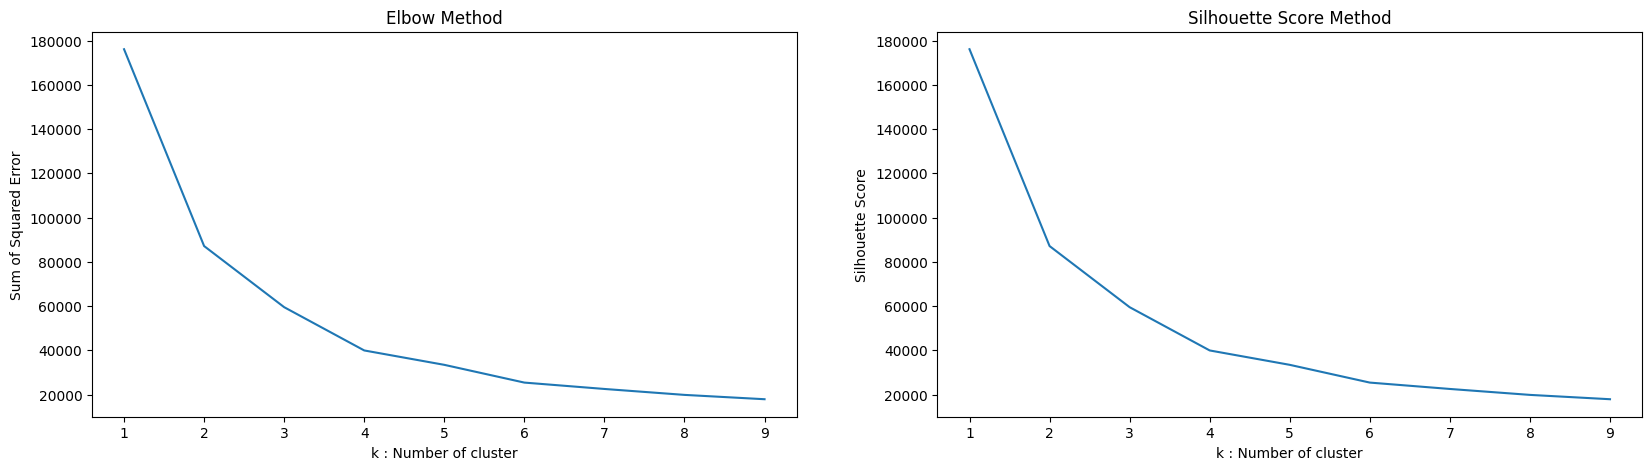

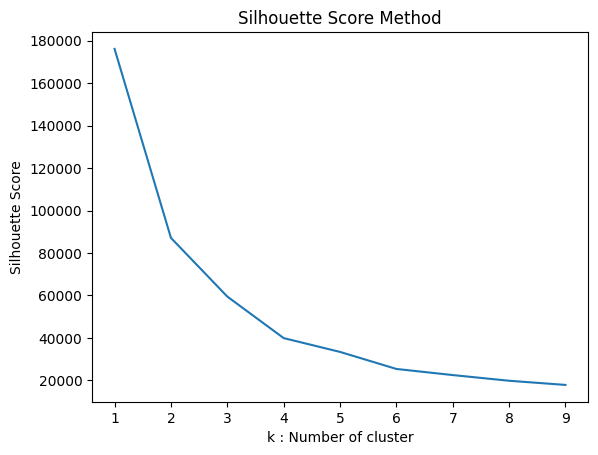

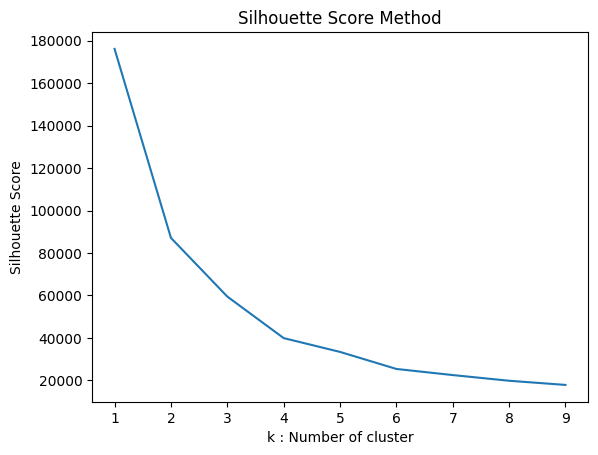

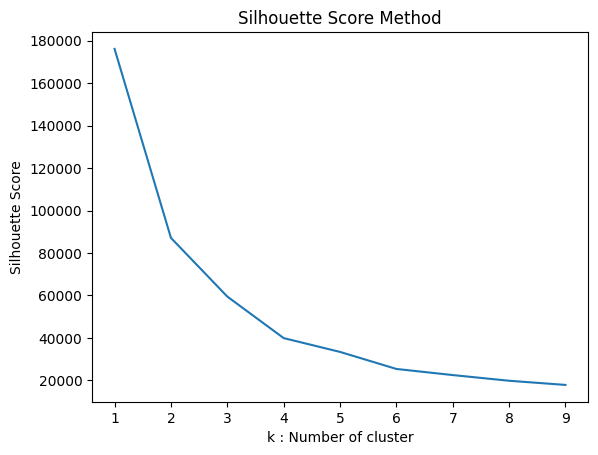

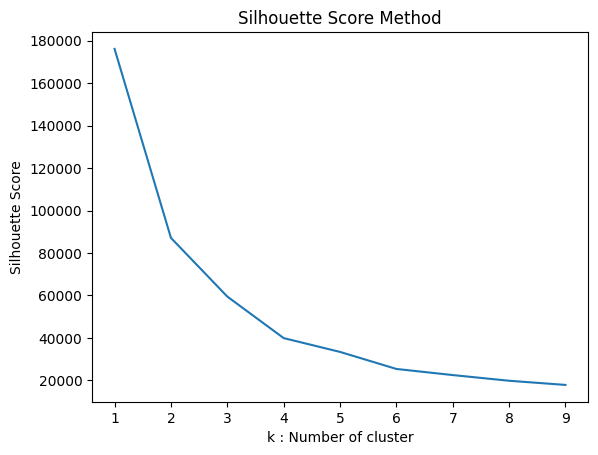

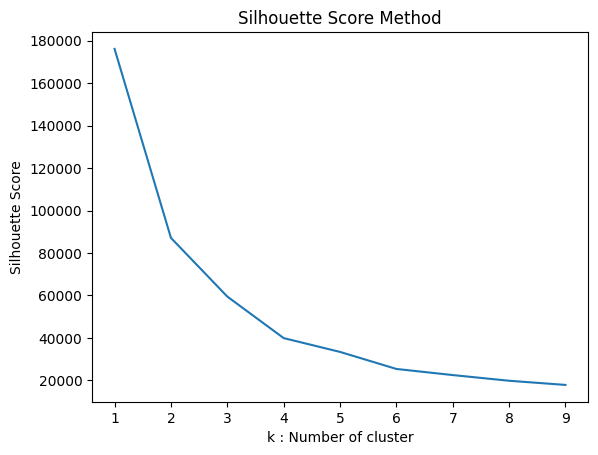

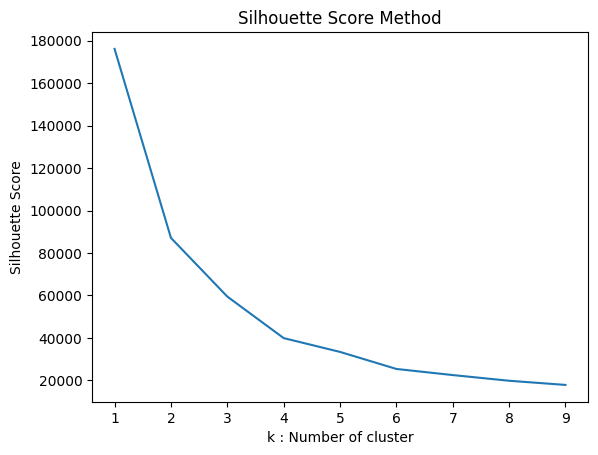

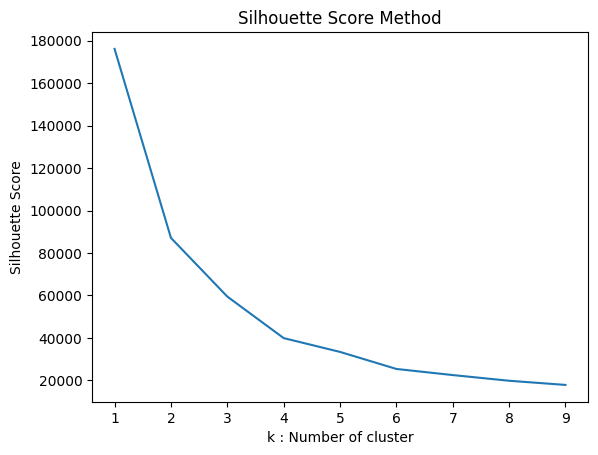

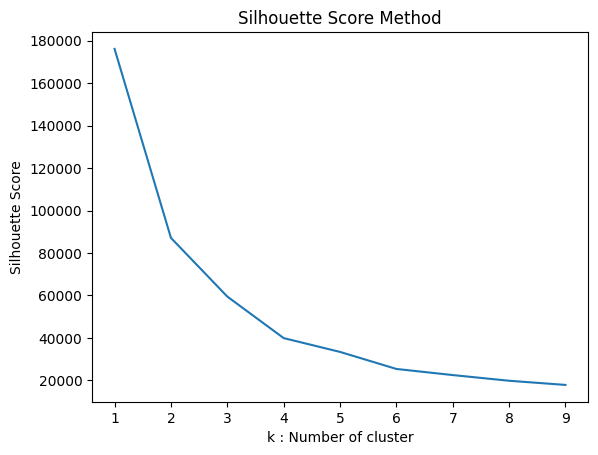

In [67]:
sse={};sil=[];kmax=10
fig=plt.subplots(nrows=1, ncols=2, figsize=(20,5))

plt.subplot(1,2,1)
for k in range(1,10):
  kmeans=KMeans(n_clusters=k, max_iter=1000).fit(m1)
  sse[k]=kmeans.inertia_

sns.lineplot(x=list(sse.keys()), y=list(sse.values()));
plt.title('Elbow Method')
plt.xlabel("k : Number of cluster")
plt.ylabel("Sum of Squared Error")

plt.subplot(1,2,2)
for k in range(2, kmax+1):
  kmeans=KMeans(n_clusters=k).fit(m1)
  labels=kmeans.labels_
  sil.append(silhouette_score(m1, labels, metric='euclidean'))
  sns.lineplot(x=list(sse.keys()), y=list(sse.values()));
  plt.title('Silhouette Score Method')
  plt.xlabel("k : Number of cluster")
  plt.ylabel("Silhouette Score")
  plt.show()

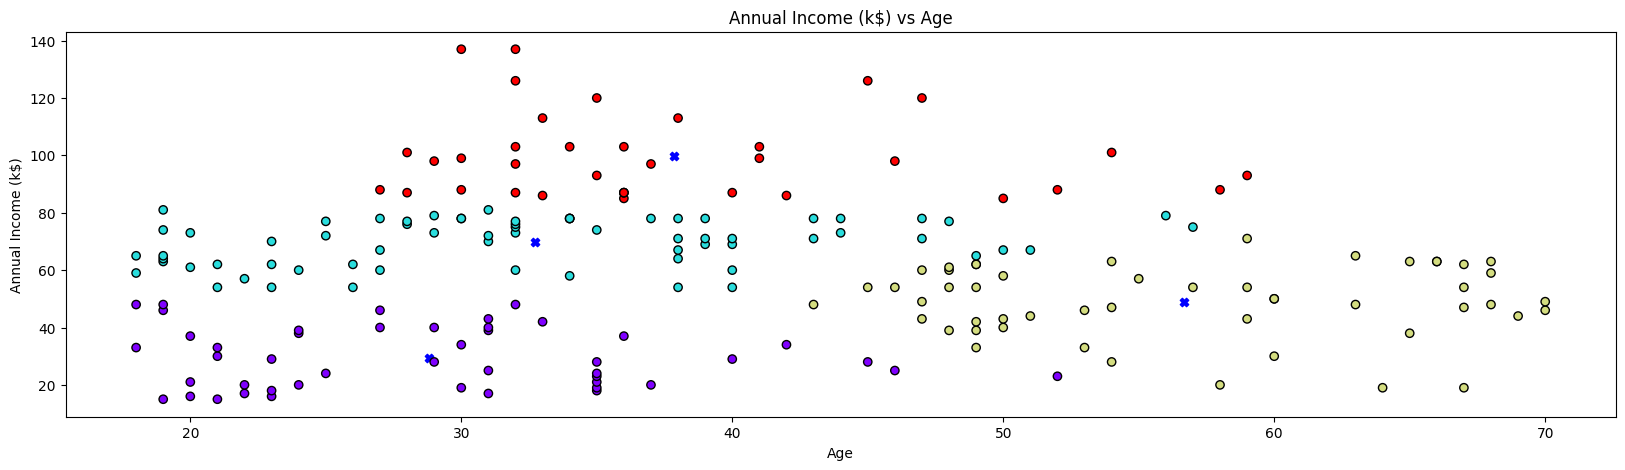

In [73]:
model=KMeans(n_clusters=4, max_iter=1000)
model.fit(m1)
cluster=model.cluster_centers_
centroids=np.array(cluster)
labels=model.labels_

plt.figure(figsize=(20,5))
plt.scatter(centroids[:,0], centroids[:,1], marker="X", color='b')
plt.scatter(x='Age', y='Annual Income (k$)', c=labels, cmap='rainbow', data=df1, edgecolor='black');
plt.title('Annual Income (k$) vs Age')
plt.xlabel('Age')
plt.ylabel('Annual Income (k$)')
plt.show();

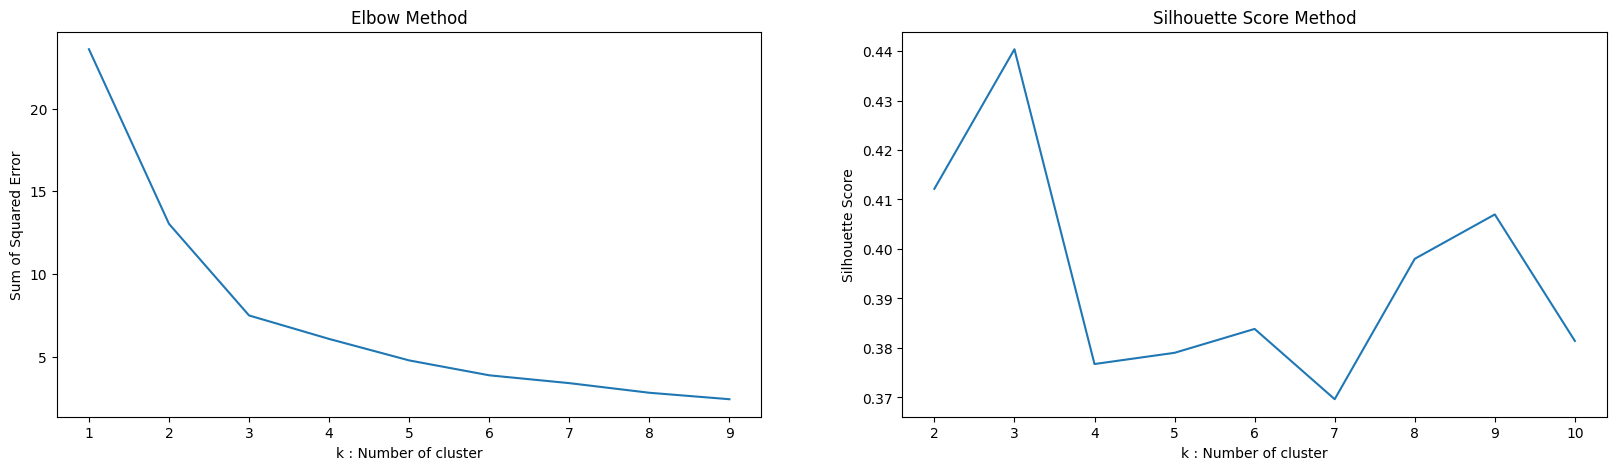

In [75]:
sse={};sil=[];kmax=10
fig=plt.subplots(nrows=1, ncols=2, figsize=(20,5))

plt.subplot(1,2,1)
for k in range(1, 10):
  kmeans=KMeans(n_clusters=k, max_iter=1000).fit(m2)
  sse[k]=kmeans.inertia_
sns.lineplot(x=list(sse.keys()),y=list(sse.values()));
plt.title('Elbow Method')
plt.xlabel("k : Number of cluster")
plt.ylabel("Sum of Squared Error")

plt.subplot(1,2,2)
for k in range(2, kmax+1):
  kmeans=KMeans(n_clusters=k).fit(m2)
  labels=kmeans.labels_
  sil.append(silhouette_score(m2,labels,metric='euclidean'))
sns.lineplot(x=range(2,kmax+1), y=sil);
plt.title('Silhouette Score Method')
plt.xlabel("k : Number of cluster")
plt.ylabel("Silhouette Score")
plt.show()

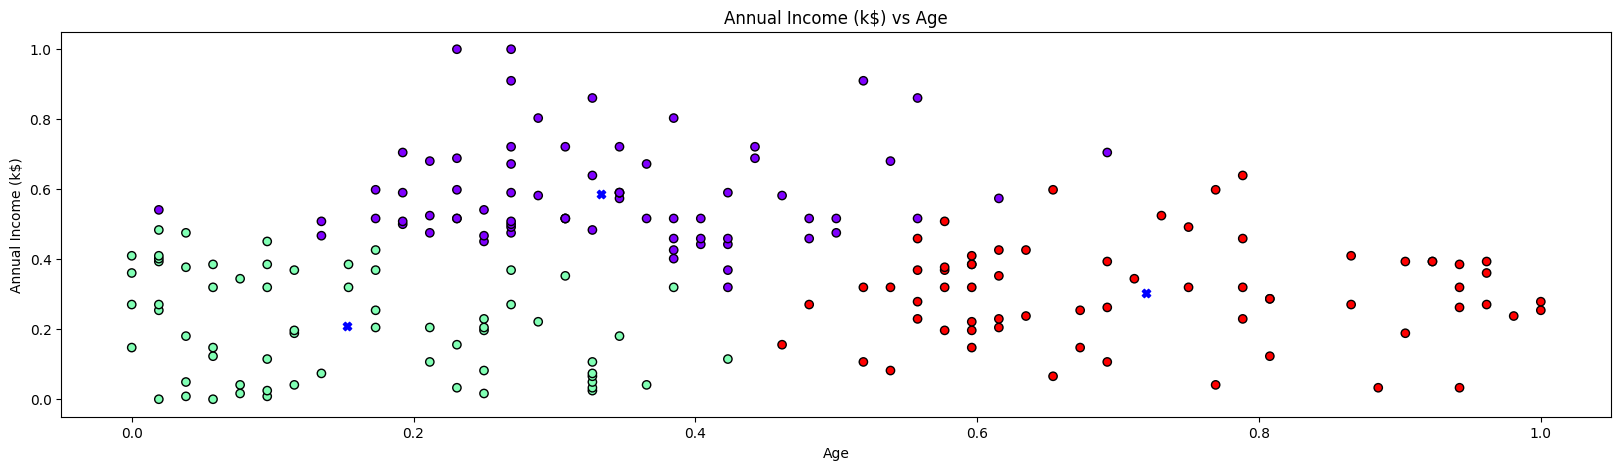

In [77]:
model=KMeans(n_clusters=3, max_iter=1000)
model.fit(m2)
cluster=model.cluster_centers_
centroids=np.array(cluster)
labels=model.labels_

plt.figure(figsize=(20,5))
plt.scatter(centroids[:,0],centroids[:,1], marker="X", color='b')
plt.scatter(x='Age', y='Annual Income (k$)', c=labels, cmap='rainbow', data=df2, edgecolor='black');
plt.title('Annual Income (k$) vs Age')
plt.xlabel('Age')
plt.ylabel('Annual Income (k$)')
plt.show();

In [78]:
m1=df1[['Age', 'Spending Score (1-100)']].values
m2=df2[['Age', 'Spending Score (1-100)']].values

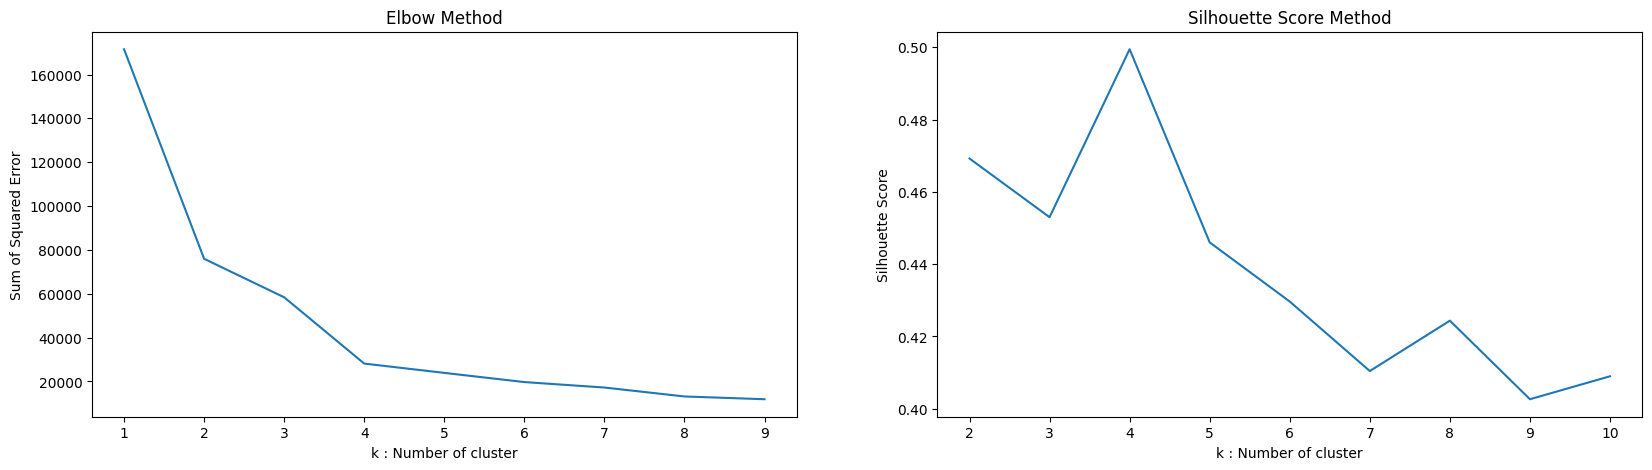

In [81]:
sse={}; sil=[]; kmax=10
fig=plt.subplots(nrows=1, ncols=2, figsize=(20,5))

plt.subplot(1,2,1)
for k in range(1,10):
  kmeans=KMeans(n_clusters=k, max_iter=1000).fit(m1)
  sse[k]=kmeans.inertia_
sns.lineplot(x=list(sse.keys()), y=list(sse.values()));
plt.title('Elbow Method')
plt.xlabel("k : Number of cluster")
plt.ylabel("Sum of Squared Error")

plt.subplot(1,2,2)
for k in range(2, kmax+1):
  kmeans=KMeans(n_clusters=k).fit(m1)
  labels=kmeans.labels_
  sil.append(silhouette_score(m1, labels, metric='euclidean'))
sns.lineplot(x=range(2,kmax+1), y=sil);
plt.title('Silhouette Score Method')
plt.xlabel("k : Number of cluster")
plt.ylabel("Silhouette Score")
plt.show()


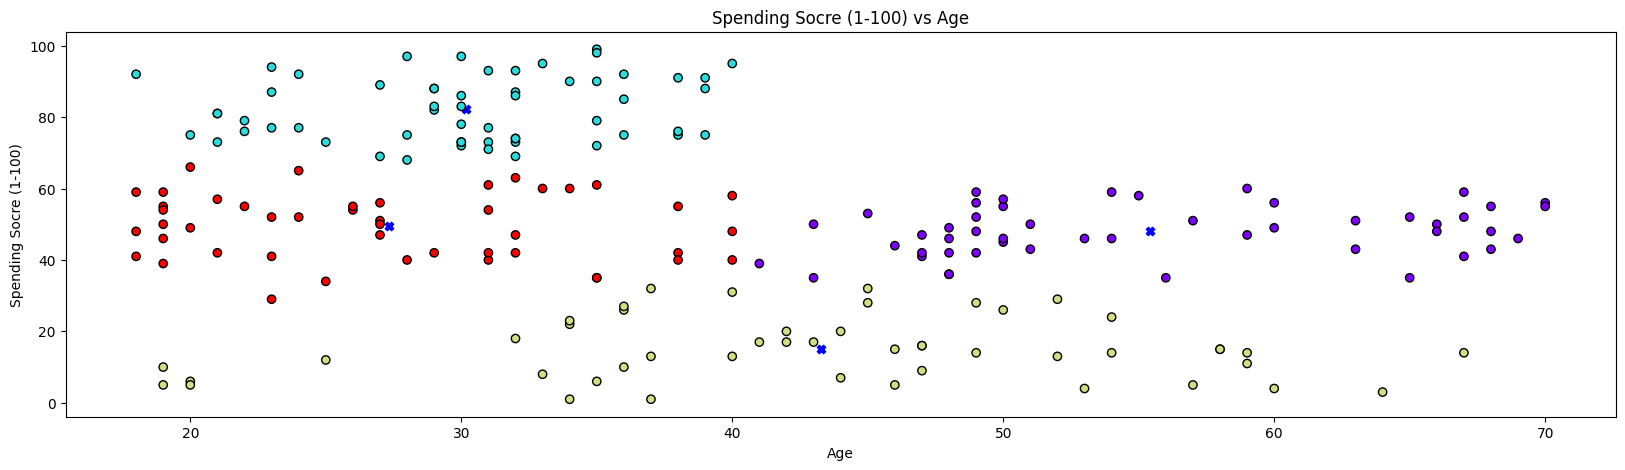

In [84]:
model=KMeans(n_clusters=4, max_iter=1000)
model.fit(m1)
cluster=model.cluster_centers_
centroids=np.array(cluster)
labels=model.labels_
plt.figure(figsize=(20,5))
plt.scatter(centroids[:,0], centroids[:,1], marker="X", color='b')
plt.scatter(x='Age', y='Spending Score (1-100)', c=labels, cmap='rainbow', data=df1, edgecolor='black');
plt.title('Spending Socre (1-100) vs Age')
plt.xlabel('Age')
plt.ylabel('Spending Socre (1-100)')
plt.show();

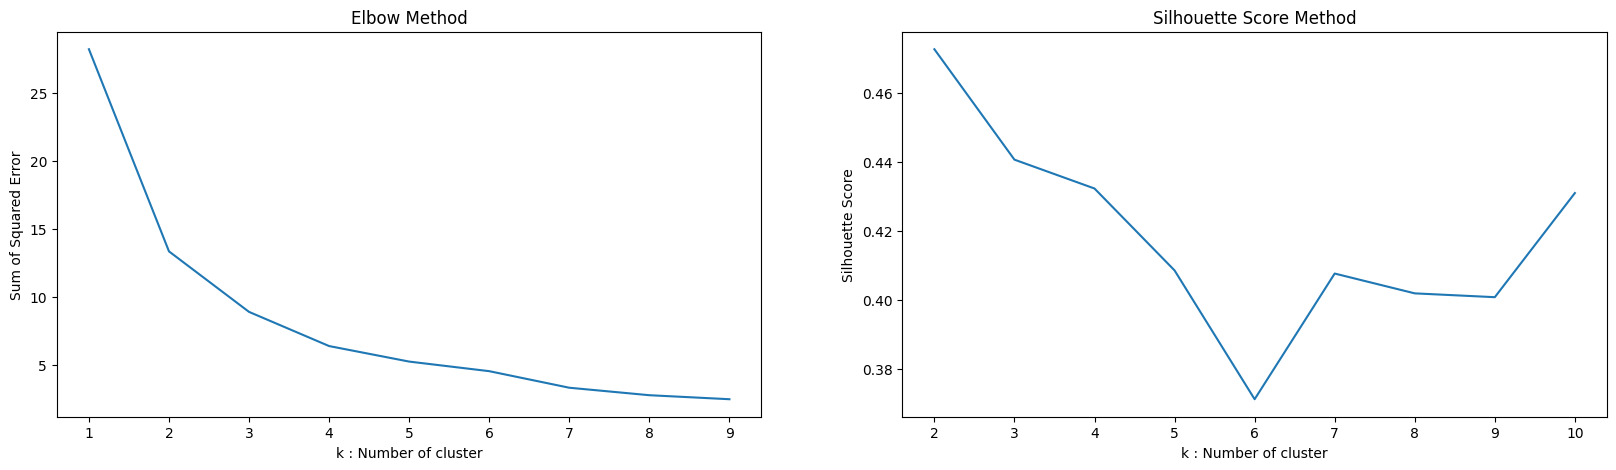

In [89]:
sse={}; sil=[]; kmax=10
fig=plt.subplots(nrows=1, ncols=2, figsize=(20,5))

plt.subplot(1,2,1)
for k in range(1,10):
  kmeans=KMeans(n_clusters=k, max_iter=1000).fit(m2)
  sse[k]=kmeans.inertia_
sns.lineplot(x=list(sse.keys()), y=list(sse.values()));
plt.title('Elbow Method')
plt.xlabel("k : Number of cluster")
plt.ylabel("Sum of Squared Error")

plt.subplot(1,2,2)
for k in range(2,kmax+1):
  kmeans=KMeans(n_clusters=k).fit(m2)
  labels=kmeans.labels_
  sil.append(silhouette_score(m2, labels, metric='euclidean'))
sns.lineplot(x=range(2,kmax+1), y=sil);
plt.title('Silhouette Score Method')
plt.xlabel("k : Number of cluster")
plt.ylabel("Silhouette Score")
plt.show()

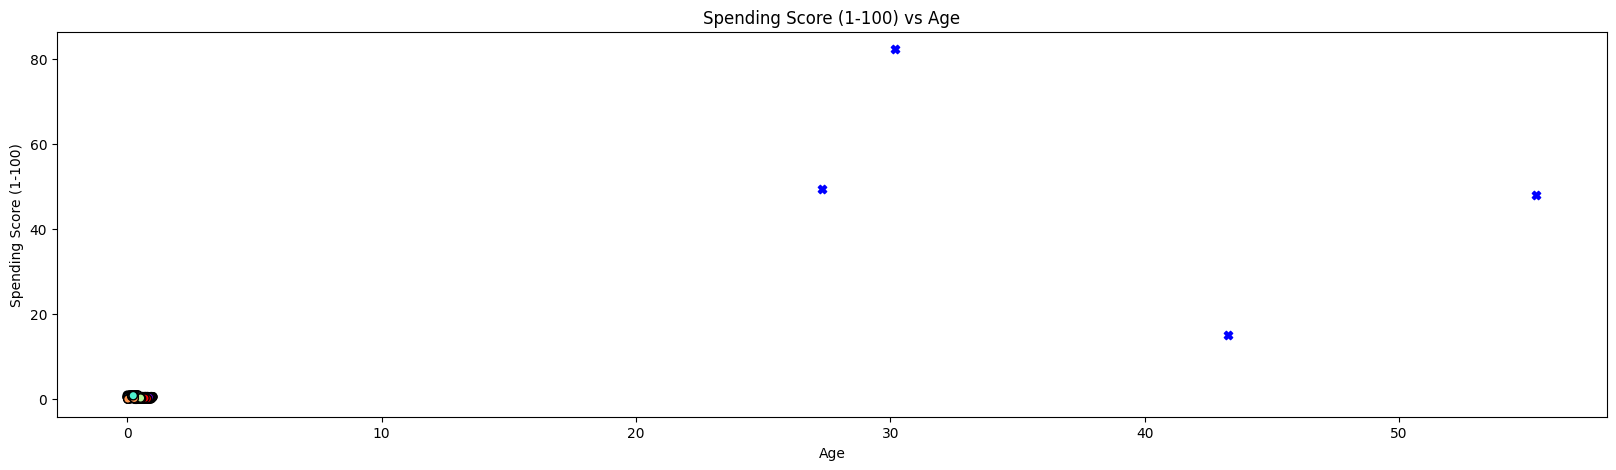

In [91]:
model=KMeans(n_clusters=6, max_iter=1000)
model.fit(m2)
cluster=model.cluster_centers_centroids=np.array(cluster)
labels=model.labels_

plt.figure(figsize=(20,5))
plt.scatter(centroids[:,0], centroids[:,1], marker="X", color='b')
plt.scatter(x='Age', y='Spending Score (1-100)', c=labels, cmap='rainbow', data=df2, edgecolor='black');
plt.title('Spending Score (1-100) vs Age')
plt.xlabel('Age')
plt.ylabel('Spending Score (1-100)')
plt.show();

In [93]:
m1=df1[['Annual Income (k$)', 'Spending Score (1-100)']].values
m2=df2[['Annual Income (k$)', 'Spending Score (1-100)']].values

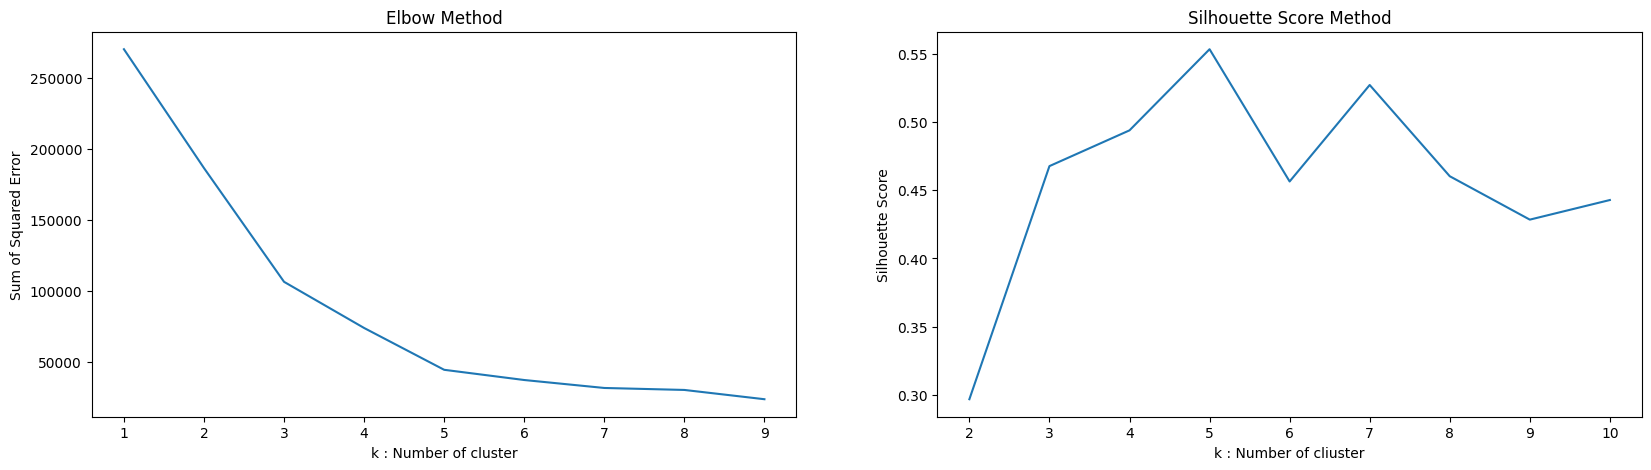

In [95]:
sse={};sil=[];kmax=10
fig=plt.subplots(nrows=1, ncols=2, figsize=(20,5))

plt.subplot(1,2,1)
for k in range(1,10):
  kmeans=KMeans(n_clusters=k, max_iter=1000).fit(m1)
  sse[k]=kmeans.inertia_
sns.lineplot(x=list(sse.keys()), y=list(sse.values()));
plt.title('Elbow Method')
plt.xlabel("k : Number of cluster")
plt.ylabel("Sum of Squared Error")

plt.subplot(1,2,2)
for k in range(2, kmax+1):
  kmeans=KMeans(n_clusters=k).fit(m1)
  labels=kmeans.labels_
  sil.append(silhouette_score(m1, labels, metric='euclidean'))
sns.lineplot(x=range(2,kmax+1), y=sil);
plt.title('Silhouette Score Method')
plt.xlabel("k : Number of cliuster")
plt.ylabel("Silhouette Score")
plt.show()

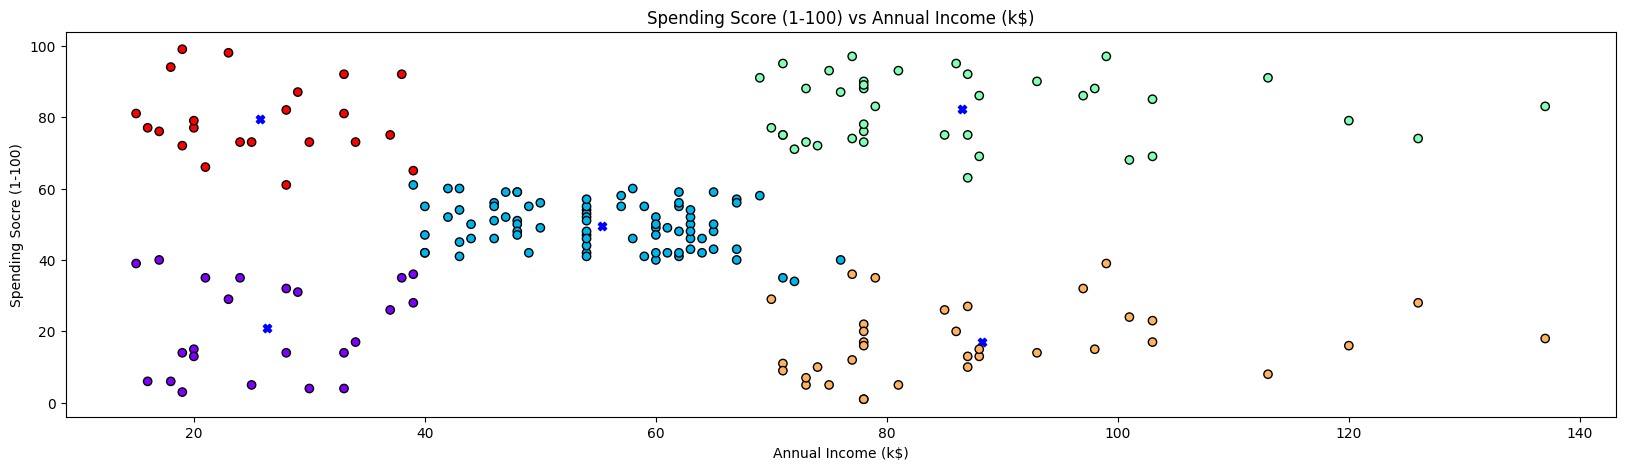

In [97]:
model=KMeans(n_clusters=5, max_iter=1000)
model.fit(m1)
cluster=model.cluster_centers_
centroids=np.array(cluster)
labels=model.labels_
plt.figure(figsize=(20,5))
plt.scatter(centroids[:,0], centroids[:,1], marker="X", color='b')
plt.scatter(x='Annual Income (k$)', y='Spending Score (1-100)', c=labels, cmap='rainbow', data=df1, edgecolor='black');
plt.title('Spending Score (1-100) vs Annual Income (k$)')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Socre (1-100)')
plt.show();

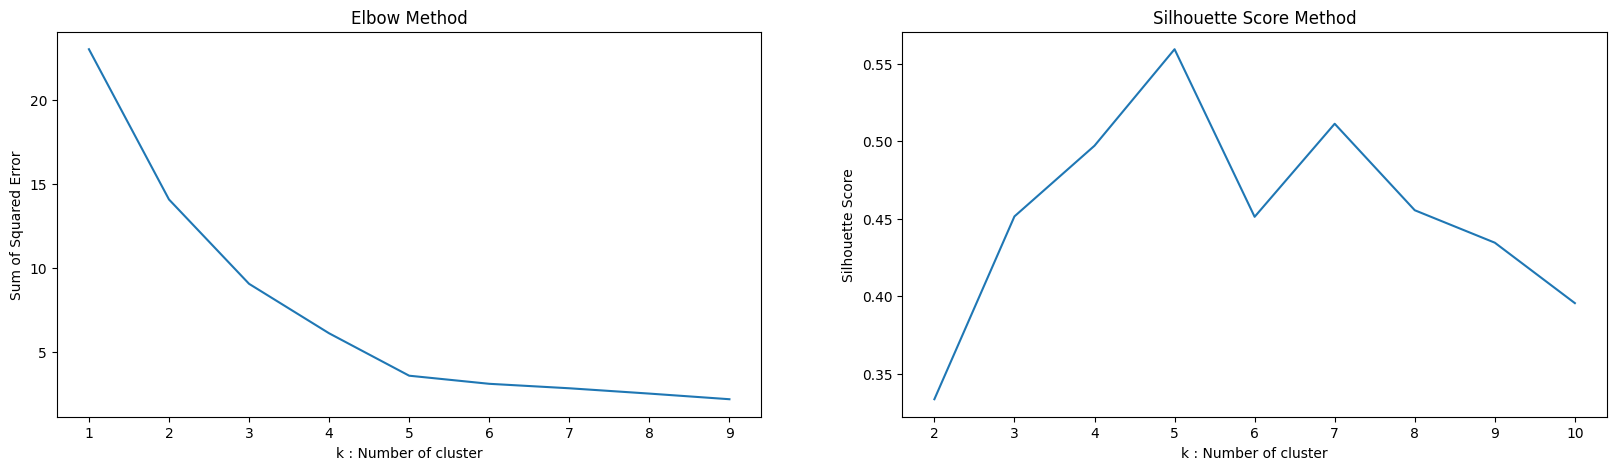

In [99]:
sse={}; sil=[]; kmax=10
fig=plt.subplots(nrows=1, ncols=2, figsize=(20,5))

plt.subplot(1,2,1)
for k in range(1,10):
  kmeans=KMeans(n_clusters=k, max_iter=1000).fit(m2)
  sse[k]=kmeans.inertia_
sns.lineplot(x=list(sse.keys()), y=list(sse.values()));
plt.title('Elbow Method')
plt.xlabel("k : Number of cluster")
plt.ylabel("Sum of Squared Error")

plt.subplot(1,2,2)
for k in range(2, kmax+1):
  kmeans=KMeans(n_clusters=k).fit(m2)
  labels=kmeans.labels_
  sil.append(silhouette_score(m2, labels, metric='euclidean'))
sns.lineplot(x=range(2,kmax+1), y=sil);
plt.title('Silhouette Score Method')
plt.xlabel("k : Number of cluster")
plt.ylabel("Silhouette Score")
plt.show()

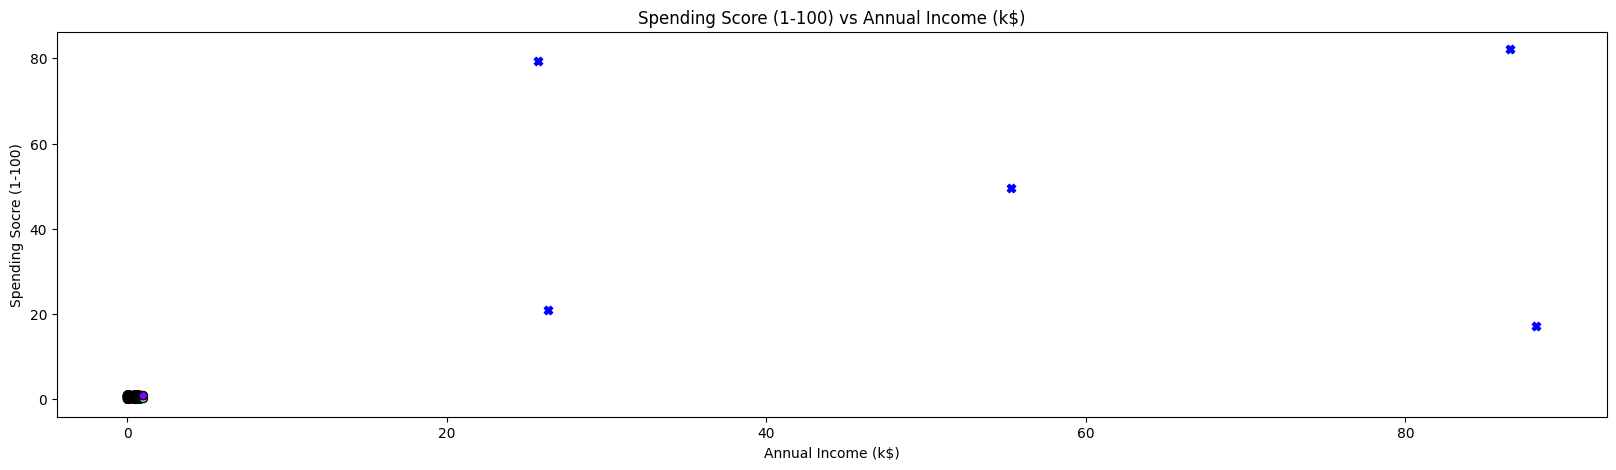

In [100]:
model=KMeans(n_clusters=5, max_iter=1000)
model.fit(m2)
cluster=model.cluster_centers_centroids=np.array(cluster)
labels=model.labels_
plt.figure(figsize=(20,5))
plt.scatter(centroids[:,0], centroids[:,1], marker="X", color='b')
plt.scatter(x='Annual Income (k$)', y='Spending Score (1-100)', c=labels, cmap='rainbow', data=df2, edgecolor='black');
plt.title('Spending Score (1-100) vs Annual Income (k$)')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Socre (1-100)')
plt.show();

In [103]:
m1=df1[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].values
m2=df2[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].values

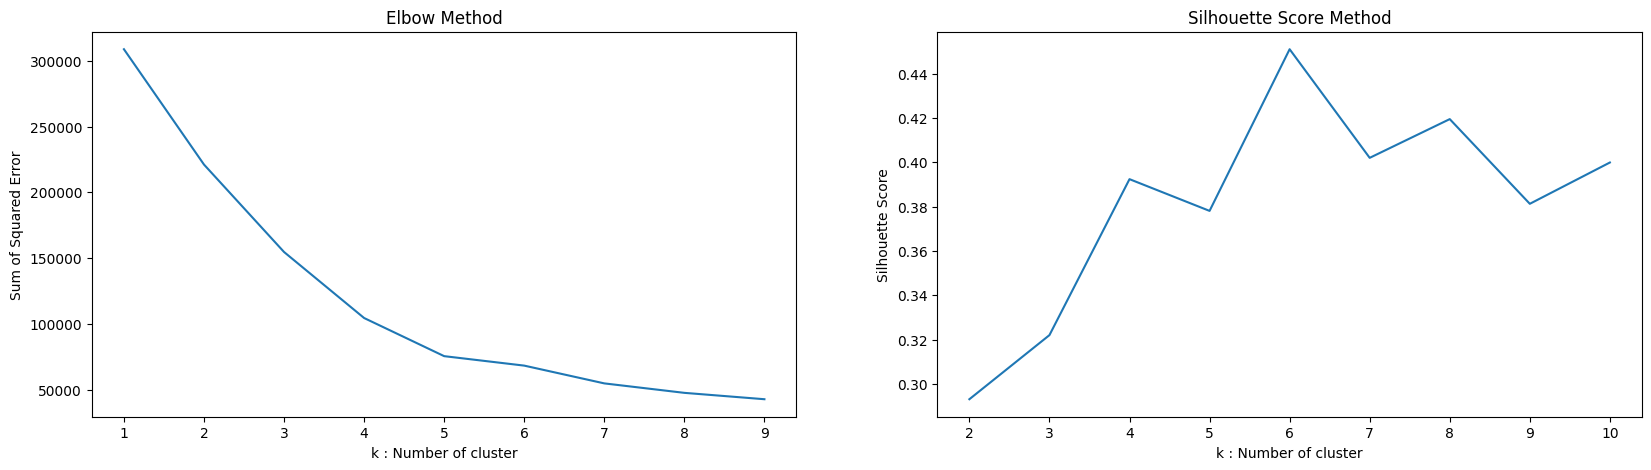

In [104]:
sse={}; sil=[]; kmax=10
fig=plt.subplots(nrows=1, ncols=2, figsize=(20,5))

plt.subplot(1,2,1)
for k in range(1,10):
  kmeans=KMeans(n_clusters=k, max_iter=1000).fit(m1)
  sse[k]=kmeans.inertia_
sns.lineplot(x=list(sse.keys()), y=list(sse.values()));
plt.title('Elbow Method')
plt.xlabel("k : Number of cluster")
plt.ylabel("Sum of Squared Error")

plt.subplot(1,2,2)
for k in range(2, kmax+1):
  kmeans=KMeans(n_clusters=k).fit(m1)
  labels=kmeans.labels_
  sil.append(silhouette_score(m1, labels, metric='euclidean'))
sns.lineplot(x=range(2,kmax+1), y=sil);
plt.title('Silhouette Score Method')
plt.xlabel("k : Number of cluster")
plt.ylabel("Silhouette Score")
plt.show()

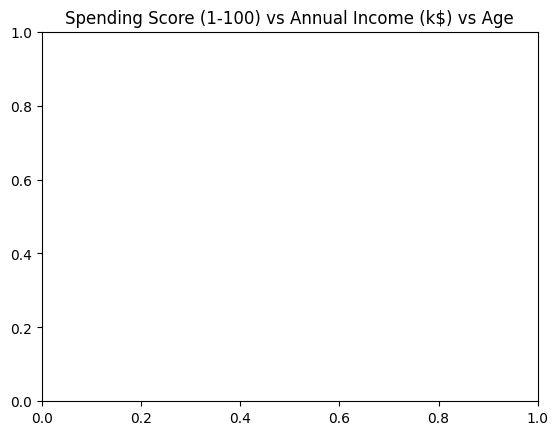

In [112]:
model=KMeans(n_clusters=6, max_iter=1000)
model.fit(m1)
cluster=model.cluster_centers_
centroids=np.array(cluster)
labels=model.labels_

fig=plt.figure()
ax=Axes3D(fig)
x=np.array(df1['Annual Income (k$)'])
y=np.array(df1['Spending Score (1-100)'])
z=np.array(df1['Age'])
ax.scatter(centroids[:,0], centroids[:,1], centroids[:,2], marker="X", color='b')
ax.scatter(x,y,z,c=y)
plt.title('Spending Score (1-100) vs Annual Income (k$) vs Age')
ax.set_xlabel('Annual Income (k$)')
ax.set_ylabel('Spending Score (1-100)')
ax.set_zlabel('Age')
plt.show();

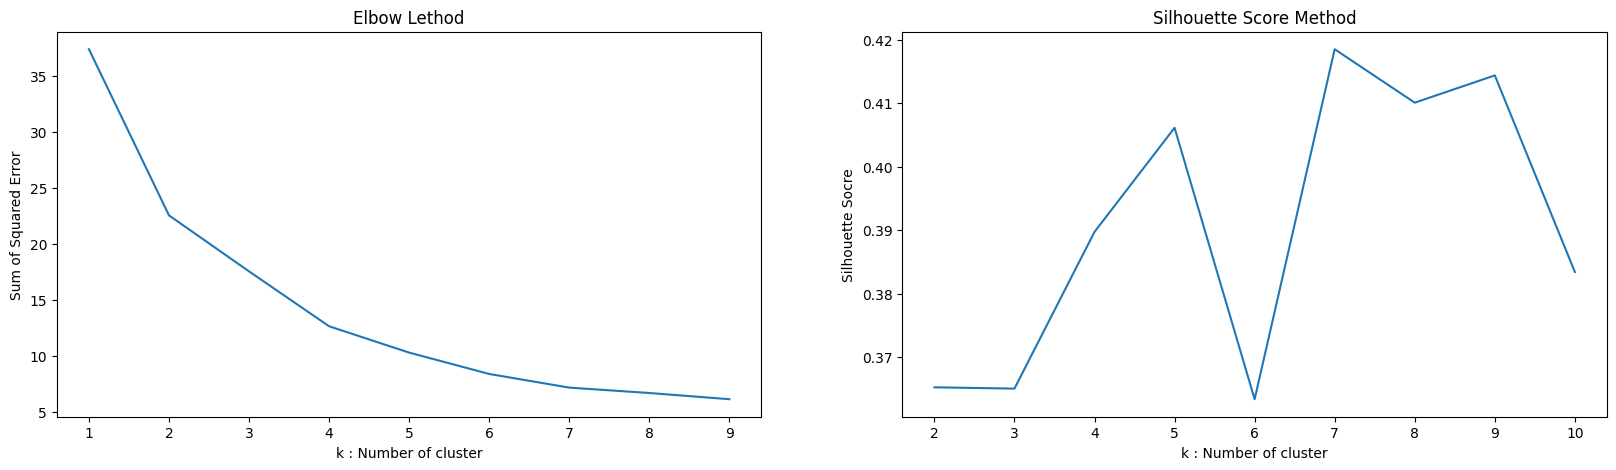

In [108]:
sse={}; sil=[]; kmax=10
fig=plt.subplots(nrows=1, ncols=2, figsize=(20,5))

plt.subplot(1,2,1)
for k in range(1,10):
  kmeans=KMeans(n_clusters=k, max_iter=1000).fit(m2)
  sse[k]=kmeans.inertia_
sns.lineplot(x=list(sse.keys()), y=list(sse.values()));
plt.title('Elbow Lethod')
plt.xlabel("k : Number of cluster")
plt.ylabel("Sum of Squared Error")

plt.subplot(1,2,2)
for k in range(2, kmax+1):
  kmeans=KMeans(n_clusters=k).fit(m2)
  labels=kmeans.labels_
  sil.append(silhouette_score(m2, labels, metric='euclidean'))
sns.lineplot(x=range(2,kmax+1), y=sil);
plt.title('Silhouette Score Method')
plt.xlabel("k : Number of cluster")
plt.ylabel("Silhouette Socre")
plt.show()

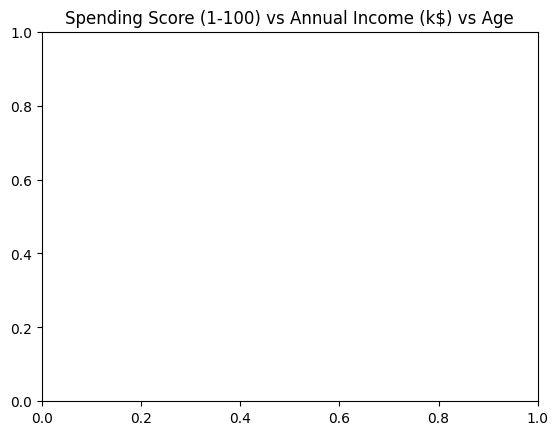

In [111]:
model=KMeans(n_clusters=6, max_iter=1000)
model.fit(m2)
cluster=model.cluster_centers_
centroids=np.array(cluster)
labels=model.labels_

fig=plt.figure()
ax=Axes3D(fig)
x=np.array(df2['Annual Income (k$)'])
y=np.array(df2['Spending Score (1-100)'])
z=np.array(df2['Age'])
ax.scatter(centroids[:,0], centroids[:,1], centroids[:,2], marker="X", color='b')
ax.scatter(x,y,z,c=y)
plt.title('Spending Score (1-100) vs Annual Income (k$) vs Age')
ax.set_xlabel('Annual Income (k$)')
ax.set_ylabel('Spending Socre (1-100)')
ax.set_zlabel('Age')
plt.show();